In [11]:
!pip install onnx -q
import numpy as np
import pandas as pd
import os
import json
import pickle
from scipy import stats
from scipy.fft import fft
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import onnx

In [12]:
DATA_DIR = "/kaggle/input/datasets/gautam0404/raw-data/raw_data"

def load_dataset(data_dir):
    X_raw, y, label_map, label_names = [], [], {}, []

    gesture_dirs = sorted(os.listdir(data_dir))
    print(f"Found {len(gesture_dirs)} gestures: {gesture_dirs}\n")

    for idx, gesture in enumerate(gesture_dirs):
        label_map[idx] = gesture
        label_names.append(gesture)
        path = os.path.join(data_dir, gesture)
        files = [f for f in os.listdir(path) if f.endswith('.npy')]

        for fname in files:
            arr = np.load(os.path.join(path, fname))
            if arr.shape == (200, 6):
                X_raw.append(arr)
                y.append(idx)
            else:
                print(f"  Skipping bad shape {arr.shape}: {fname}")

        print(f"  [{gesture}]: {len(files)} samples loaded")

    return np.array(X_raw), np.array(y), label_map, label_names

X_raw, y, label_map, label_names = load_dataset(DATA_DIR)
print(f"\nDataset shape: {X_raw.shape}")  # (90, 200, 6)
print(f"Classes: {label_map}")

Found 2 gestures: ['no', 'yes']

  [no]: 40 samples loaded
  [yes]: 40 samples loaded

Dataset shape: (80, 200, 6)
Classes: {0: 'no', 1: 'yes'}


In [13]:
def augment_window(window: np.ndarray) -> np.ndarray:
    aug = window.copy()

    # 1. Additive Gaussian noise
    if np.random.rand() < 0.5:
        aug += np.random.normal(0, 0.02, aug.shape)

    # 2. DC offset shift
    if np.random.rand() < 0.5:
        aug += np.random.uniform(-0.1, 0.1, (1, 6))

    # 3. Time scaling ±10%
    if np.random.rand() < 0.5:
        factor = np.random.uniform(0.9, 1.1)
        new_len = int(aug.shape[0] * factor)
        aug = np.array([
            np.interp(
                np.linspace(0, aug.shape[0]-1, aug.shape[0]),
                np.linspace(0, aug.shape[0]-1, new_len),
                np.interp(np.linspace(0, aug.shape[0]-1, new_len),
                          np.arange(aug.shape[0]), aug[:, i])
            ) for i in range(6)
        ]).T

    # 4. Axis scaling
    if np.random.rand() < 0.5:
        scale = np.random.uniform(0.9, 1.1, (1, 6))
        aug *= scale

    return aug.astype(np.float32)

def augment_dataset(X, y, n_augments=5):
    X_aug, y_aug = [X.copy()], [y.copy()]
    for _ in range(n_augments):
        batch = np.array([augment_window(x) for x in X])
        X_aug.append(batch)
        y_aug.append(y.copy())
    return np.vstack(X_aug), np.concatenate(y_aug)

X_aug, y_aug = augment_dataset(X_raw, y, n_augments=5)
print(f"After augmentation: {X_aug.shape}")  # (540, 200, 6)

After augmentation: (480, 200, 6)


In [14]:
def extract_features(window: np.ndarray) -> np.ndarray:
    features = []

    for i in range(6):
        col = window[:, i]
        features.append(np.mean(col))
        features.append(np.std(col))
        features.append(np.min(col))
        features.append(np.max(col))
        features.append(np.max(col) - np.min(col))
        features.append(float(stats.skew(col)))
        features.append(float(stats.kurtosis(col)))
        features.append(np.sum(np.abs(col)) / len(col))

        # Zero crossing rate
        zcr = np.sum(np.diff(np.sign(col)) != 0) / len(col)
        features.append(zcr)

        # Top 5 FFT magnitudes
        fft_vals = np.abs(fft(col))[:len(col)//2]
        top5 = np.sort(fft_vals)[-5:]
        features.extend(top5)

    # Cross-axis correlations (accel)
    accel = window[:, :3]
    features.append(np.corrcoef(accel[:, 0], accel[:, 1])[0, 1])
    features.append(np.corrcoef(accel[:, 1], accel[:, 2])[0, 1])
    features.append(np.corrcoef(accel[:, 0], accel[:, 2])[0, 1])

    # Signal magnitude vector
    smv = np.sqrt(np.sum(accel**2, axis=1))
    features.append(np.mean(smv))
    features.append(np.std(smv))

    return np.array(features, dtype=np.float32)

X_feat     = np.array([extract_features(w) for w in X_raw])
X_feat_aug = np.array([extract_features(w) for w in X_aug])
print(f"Feature vector size: {X_feat.shape[1]}")

Feature vector size: 89


In [15]:
# Run this BEFORE Cell 5

# Step 1 — Split on original data
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2 — Augment train only
X_train_aug, y_train_aug = augment_dataset(X_train_raw, y_train_raw, n_augments=5)

# Step 3 — Compute normalization stats from train only
train_mean = X_train_aug.mean(axis=(0, 1))  # (6,)
train_std  = X_train_aug.std(axis=(0, 1)) + 1e-8

np.save("norm_mean.npy", train_mean)
np.save("norm_std.npy",  train_std)

print(f"Train size : {X_train_aug.shape}")
print(f"Val size   : {X_val_raw.shape}")
print(f"Train mean : {train_mean}")
print(f"Train std  : {train_std}")

Train size : (384, 200, 6)
Val size   : (16, 200, 6)
Train mean : [ -0.06112786   0.16173234   2.10087333   5.62366987  -0.89893333
 -21.48896959]
Train std  : [ 0.26151109  0.27487981  0.43789259 37.83729277 56.84795336 60.64925564]


Random Forest Results on Held-Out Validation Set:
              precision    recall  f1-score   support

          no       1.00      1.00      1.00         8
         yes       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



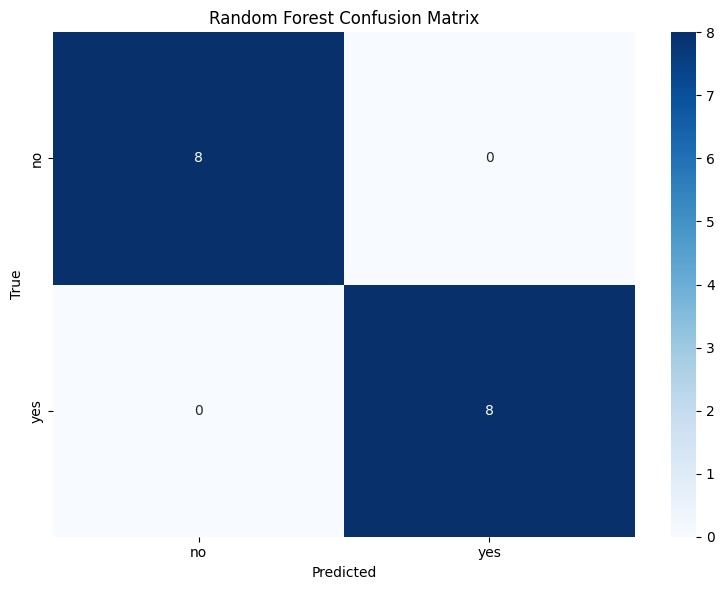

In [16]:
# Cell 5 — Random Forest (corrected, no leakage)

# Extract features from already-split data
X_feat_train_aug = np.array([extract_features(w) for w in X_train_aug])
X_feat_val       = np.array([extract_features(w) for w in X_val_raw])

scaler = StandardScaler()
X_feat_train_scaled = scaler.fit_transform(X_feat_train_aug)
X_feat_val_scaled   = scaler.transform(X_feat_val)  # transform only, never fit on val

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_feat_train_scaled, y_train_aug)
preds = clf.predict(X_feat_val_scaled)

print("Random Forest Results on Held-Out Validation Set:")
print(classification_report(y_val_raw, preds, target_names=label_names))

cm = confusion_matrix(y_val_raw, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_names,
            yticklabels=label_names,
            cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("rf_confusion.png")
plt.show()

Training on: cpu
Epoch  10/80 | Train: 1.0000 | Val: 1.0000
Epoch  20/80 | Train: 1.0000 | Val: 1.0000
Epoch  30/80 | Train: 1.0000 | Val: 1.0000
Epoch  40/80 | Train: 1.0000 | Val: 1.0000
Epoch  50/80 | Train: 1.0000 | Val: 1.0000
Epoch  60/80 | Train: 1.0000 | Val: 1.0000
Epoch  70/80 | Train: 1.0000 | Val: 1.0000
Epoch  80/80 | Train: 1.0000 | Val: 1.0000


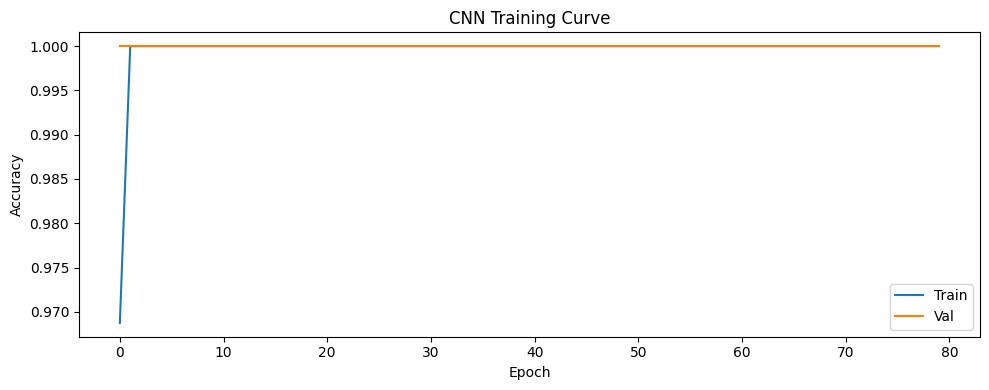

In [17]:
class GestureDataset(Dataset):
    def __init__(self, X, y, mean, std):
        X_norm = (X - mean[np.newaxis, np.newaxis, :]) / std[np.newaxis, np.newaxis, :]
        self.X = torch.tensor(X_norm.transpose(0, 2, 1), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class GestureCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(6, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Split: 80% train, 20% val (stratified)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42)

train_ds = GestureDataset(X_train_aug, y_train_aug, train_mean, train_std)
val_ds   = GestureDataset(X_val_raw,   y_val_raw,   train_mean, train_std)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

n_classes = len(label_map)
model = GestureCNN(n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.CrossEntropyLoss()

EPOCHS = 80
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    correct, total = 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    train_acc = correct / total

    # Validate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += len(yb)
    val_acc = correct / total

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    scheduler.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(train_accs, label='Train')
plt.plot(val_accs,   label='Val')
plt.title("CNN Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("cnn_training.png")
plt.show()

              precision    recall  f1-score   support

          no       1.00      1.00      1.00         8
         yes       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



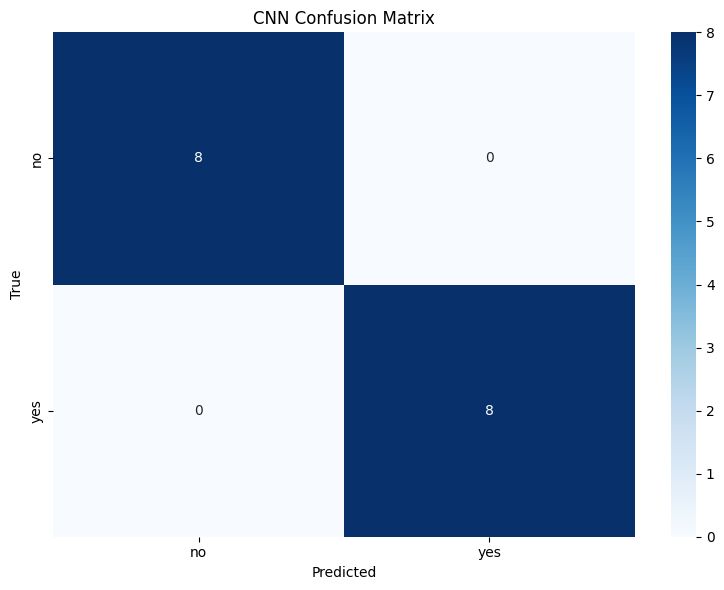

In [18]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in val_dl:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print(classification_report(all_true, all_preds, target_names=label_names))

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_names,
            yticklabels=label_names,
            cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("cnn_confusion.png")
plt.show()

In [19]:
!pip install onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.2 MB/s eta 0:00:00


In [20]:
model.eval()
dummy = torch.randn(1, 6, 200).to(device)

torch.onnx.export(
    model, dummy,
    "gesture_model.onnx",
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input':  {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

# Save label map
with open("label_map.json", "w") as f:
    json.dump({str(k): v for k, v in label_map.items()}, f)

# Save scaler (for RF inference if needed)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Exported: gesture_model.onnx, label_map.json, scaler.pkl")
print("Download these 3 files from Kaggle output.")

/tmp/ipykernel_55/19895813.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0426 02:04:32.924000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `GestureCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GestureCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Exported: gesture_model.onnx, label_map.json, scaler.pkl
Download these 3 files from Kaggle output.
